In [1]:
import random
import numpy as np
import sys
import time
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import copy
from os import initgroups
from collections import deque

In [2]:
# constantes
CAMINO = 0
PARED = 1
ORIGEN = 2
META = 3
VISITADO = 4
SOLUCION = 5

# punto de partida
START_X = 1
START_Y = 1

# Paleta de colores: [Blanco, Negro, Azul, Rojo, Celeste, Amarillo]
colores_laberinto = ListedColormap(['#FFFFFF', '#1A1A1A', '#007BFF', '#DC3545', '#AED6F1', '#F1C40F'])

# parametros
sys.setrecursionlimit(5000)
probabilidad_romper_pared=0.05
ANCHO = 200
ALTO = 200

Generando y dibujando laberinto de 200x200...


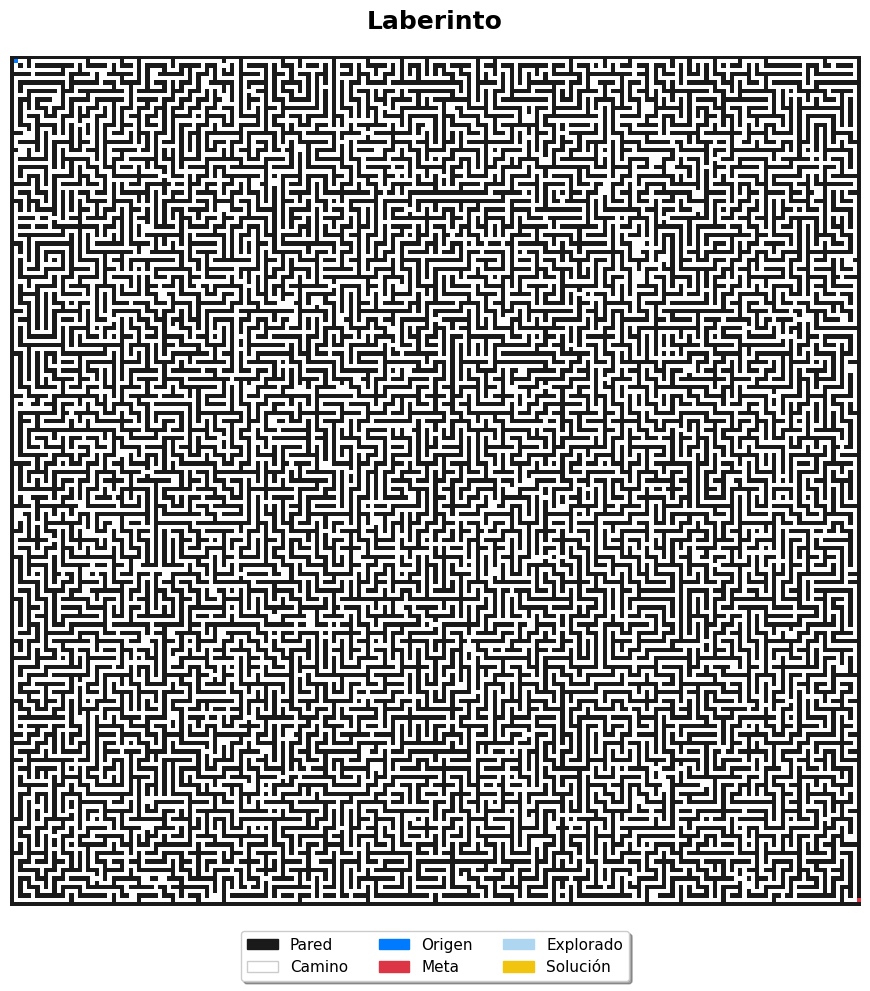

Grafo generado con 20732 nodos transitables.


In [12]:
"""
    Genera una matriz bidimensional que representa un laberinto aleatorio
    utilizando búsqueda en profundidad (DFS) con backtracking.

    Args:
        ancho (int): El número de columnas (se ajustará a impar).
        alto (int): El número de filas (se ajustará a impar).
        probabilidad_romper (float): probabilidad [0 a 1] de romper una pared en cada casilla

    Returns:
        list[list[int]]: Matriz con valores CAMINO, PARED, ORIGEN y META.
"""
def generar_laberinto(ancho, alto, probabilidad_romper):
    if ancho % 2 == 0: ancho += 1
    if alto % 2 == 0: alto += 1

    # Inicializar lleno de Paredes
    laberinto = [[PARED for _ in range(ancho)] for _ in range(alto)]

    def excavar(x, y):
        laberinto[y][x] = CAMINO
        direcciones = [(0, -2), (2, 0), (0, 2), (-2, 0)]
        random.shuffle(direcciones)

        for dx, dy in direcciones:
            nx, ny = x + dx, y + dy
            if 1 <= nx < ancho - 1 and 1 <= ny < alto - 1 and laberinto[ny][nx] == PARED:
                laberinto[y + dy // 2][x + dx // 2] = CAMINO
                excavar(nx, ny)

    # 1. Generar laberinto base (Perfecto)
    inicio_x = random.randrange(1, ancho, 2)
    inicio_y = random.randrange(1, alto, 2)
    excavar(inicio_x, inicio_y)

    # 2. Romper paredes aleatoriamente para crear ciclos (Caminos múltiples)
    for y in range(1, alto - 1):
        for x in range(1, ancho - 1):
            if laberinto[y][x] == PARED:
                # Solo romper si la pared separa dos caminos (evita áreas abiertas feas)
                # Revisar si hay caminos a los lados (horizontal o vertical)
                es_pared_horizontal = (laberinto[y][x-1] == CAMINO and laberinto[y][x+1] == CAMINO)
                es_pared_vertical = (laberinto[y-1][x] == CAMINO and laberinto[y+1][x] == CAMINO)

                if (es_pared_horizontal or es_pared_vertical) and random.random() < probabilidad_romper:
                    laberinto[y][x] = CAMINO

    # 3. Establecer Puntos de Interés
    laberinto[START_Y][START_X] = ORIGEN
    laberinto[alto - 2][ancho - 1] = META

    return laberinto
"""
    Usa Matplotlib para renderizar la matriz del laberinto con colores personalizados y leyenda.
"""
def dibujar_laberinto_grafico(laberinto):
    # Crear la figura y los ejes
    fig, ax = plt.subplots(figsize=(12, 10))

    # IMPORTANTE: vmax=5 para que reconozca los valores de VISITADO y SOLUCION
    # vmin=0 (Camino) hasta vmax=5 (Solución)
    img = ax.imshow(laberinto, cmap=colores_laberinto, interpolation='nearest', vmin=0, vmax=5)

    ax.axis('off')
    plt.title("Laberinto", fontsize=18, fontweight='bold', pad=20)

    # --- Leyenda Actualizada con 6 estados ---
    parches = [
        mpatches.Patch(color='#1A1A1A', label='Pared'),
        mpatches.Patch(color='#FFFFFF', label='Camino', ec='#CCCCCC'),
        mpatches.Patch(color='#007BFF', label='Origen'),
        mpatches.Patch(color='#DC3545', label='Meta'),
        mpatches.Patch(color='#AED6F1', label='Explorado'),
        mpatches.Patch(color='#F1C40F', label='Solución')
    ]

    ax.legend(handles=parches,
              loc='upper center',
              bbox_to_anchor=(0.5, -0.02),
              fancybox=True,
              shadow=True,
              ncol=3, # En dos filas de 3 queda más ordenado
              fontsize=11)

    plt.tight_layout()
    plt.show()

"""
    Encuentra las coordenadas (f, c) de un valor específico.
"""
def obtener_posicion(laberinto, valor):

    for f, fila in enumerate(laberinto):
        for c, celda in enumerate(fila):
            if celda == valor:
                return (f, c)
    return None

print(f"Generando y dibujando laberinto de {ANCHO}x{ALTO}...")
laberinto = generar_laberinto(ANCHO, ALTO, probabilidad_romper_pared)

dibujar_laberinto_grafico(laberinto)

def construir_grafo(laberinto):

    filas = len(laberinto) # cantidad de n-tuplas (listas)
    columnas = len(laberinto[0]) # número de elementos de una n-tupla
    laberinto_grafos = {} # todos los puntos transitables del laberinto
    transitables = {CAMINO, ORIGEN, META} # define que puntos son transitables

    for f in range(filas):
      for c in range(columnas):

        if laberinto[f][c] in transitables:# Si la celda es transitable, se agrega al grafo
            nodo_actual = (f, c) # La posición en que estamos
            laberinto_grafos[nodo_actual] = []
            for df, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:  # itera sobre las 4 direcciones (Arriba, Abajo, Izquierda, Derecha)
              nf, nc = f + df, c + dc # crea nuevas posiciones de casillas para añadirlas al grafo
              if 0 <= nf < filas and 0 <= nc < columnas: # verifica que las nuevas casillas esten dentro del laberinto
                if laberinto[nf][nc] in transitables:# Revisa las 4 celdas  que rodean a el nodo actual (en la primera iteración el origen)
                  laberinto_grafos[nodo_actual].append((nf, nc)) # Añade a aquellas casillas que sean camino y rodeen a el nodo actual
    return laberinto_grafos  # retorna la lista de duplas de coordenadas que son camino en el laberinto

grafo = construir_grafo(laberinto) # variable que almacena la matriz de caminos del laberinto original

print(f"Grafo generado con {len(grafo)} nodos transitables.") # dice cuantos nodos transitables hay


# Copia del laberinto original y la matriz de caminos

In [4]:
laberinto_1 = copy.deepcopy(laberinto)
Matriz_original = construir_grafo(laberinto)

# DFS

EL camino encontrado tiene 6236 pasos.

El tiempo de ejecución fue: 0.06861662864685059 segundos

EL conjunto de tuplas en la solución (Y, X):

[(1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (5, 2), (5, 3), (5, 4), (5, 5), (4, 5), (3, 5), (2, 5), (1, 5), (1, 6), (1, 7), (1, 8), (1, 9), (1, 10), (1, 11), (1, 12), (1, 13), (1, 14), (1, 15), (2, 15), (3, 15), (3, 14), (3, 13), (3, 12), (3, 11), (4, 11), (5, 11), (5, 12), (5, 13), (6, 13), (7, 13), (8, 13), (9, 13), (10, 13), (11, 13), (11, 14), (11, 15), (12, 15), (13, 15), (13, 16), (13, 17), (12, 17), (12, 18), (12, 19), (13, 19), (14, 19), (15, 19), (16, 19), (17, 19), (18, 19), (19, 19), (20, 19), (21, 19), (21, 20), (21, 21), (21, 22), (21, 23), (22, 23), (23, 23), (23, 22), (23, 21), (24, 21), (25, 21), (25, 20), (25, 19), (25, 18), (25, 17), (24, 17), (23, 17), (22, 17), (21, 17), (21, 16), (21, 15), (22, 15), (23, 15), (24, 15), (25, 15), (25, 14), (25, 13), (24, 13), (23, 13), (23, 12), (23, 11), (24, 11), (25, 11), (26, 11), (27, 11),

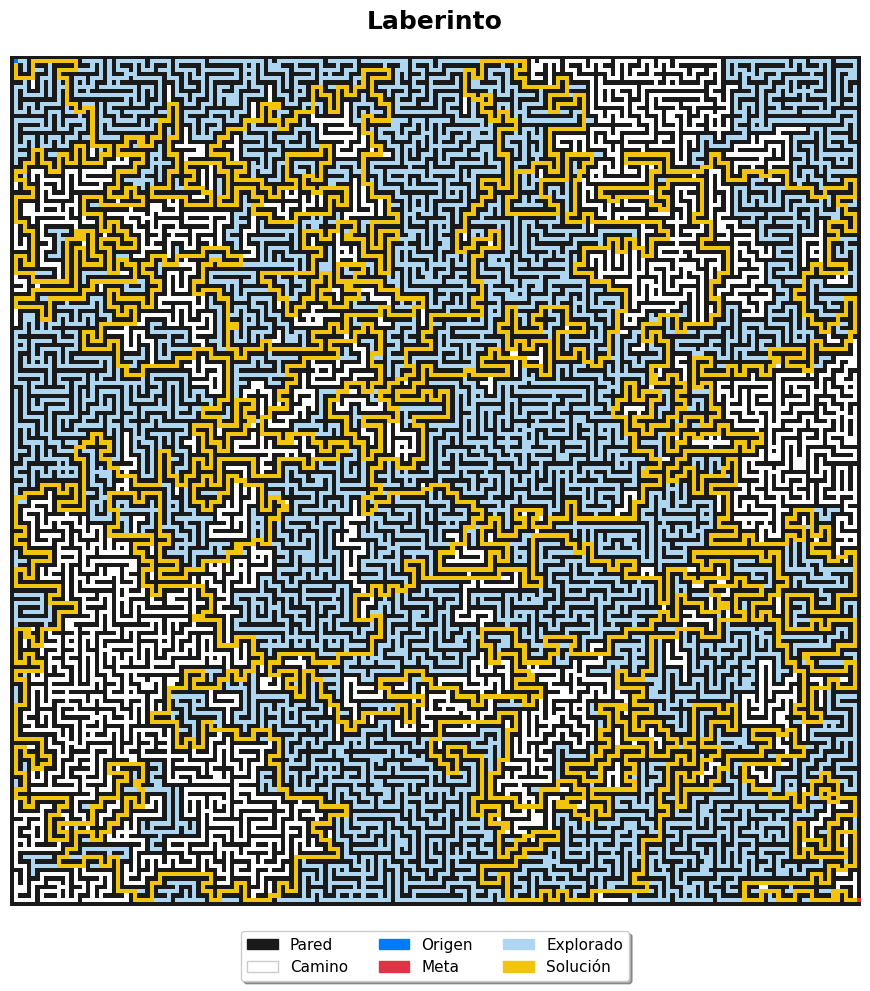

{'tiempo': 0.06861662864685059, 'visitados': 14472, 'camino': 6236}

In [5]:

class DFS: # clase que describe el comportamiento y atributos de los nodos para este método
  def __init__(self, y, x, padre=None): # función que define que atributos tiene cada nodo en este caso un nodo padre que se asignara luego y sus coordenadas de fila y columna
    self.y = y
    self.x = x
    self.padre = padre

  def obtener_posicion(self): # función que resume los atributos de fila y columna como una dupla
    return (self.y, self.x)


def camino_DFS(Matriz_original, graficar=True): # función que busca el camino que resuelve el laberinto
  laberinto_DFS = copy.deepcopy(Matriz_original) # genero una copia de la matriz de caminos del laberinto original que funcionara como el mapa en donde se mueve el algoritmo

  tiempo_ini_DFS = time.time() # función para calcular el tiempo que tarda en ejecutarse todo el algoritmo
  origen_DFS = obtener_posicion(laberinto_DFS, ORIGEN) # variable que almacena la posición del origen del laberinto
  nodo_or_DFS = DFS(origen_DFS[0], origen_DFS[1]) # variable que crea el nodo origen como una dupla
  stack = [nodo_or_DFS] # lista que almacenará los nodos

  visitados = set() # conjunto que almacena las coordenadas de los nodos visitados, este conjunto no permite repetidos
  visitados.add(nodo_or_DFS.obtener_posicion()) # almacena las coordenadas del origen en un conjunto
  movimientos = [(1, 0), (-1, 0), (0, 1), (0, -1)] # declara los movimientos posibles como duplas
  nodo_meta = None # variable que luego es reemplazada para terminar el ciclo

  while len(stack) > 0:
    nodo_actual = stack.pop(-1) # crea un nodo que almacena la última dupla que entro y elimina esa misma dupla de la lista LIFO
    posicion_actual = nodo_actual.obtener_posicion() # variable que almacena las coordenadas del nodo

    if laberinto_DFS[nodo_actual.y][nodo_actual.x] == META: # verifica si las coordenadas se corresponden con la meta del laberinto original
      nodo_meta = nodo_actual # reemplaza el valor de nodo meta por el nodo actual y termina el ciclo
      break
    if laberinto_DFS[nodo_actual.y][nodo_actual.x] not in (ORIGEN, META): # verifica si las coordenadas se corresponden con las del origen y la meta del laberinto original
      laberinto_DFS[nodo_actual.y][nodo_actual.x] = VISITADO # define una variable que almacena la dupla de coordenadas para el nodo actual
    for dy, dx in movimientos: # iteración que crea los siguientes nodos a explorar
      y_hijo = nodo_actual.y + dy # siguiente fila para el nodo hijo
      x_hijo = nodo_actual.x + dx # siguiente columna para el nodo hijo

      if 0 <= y_hijo < len(laberinto_DFS) and 0 <= x_hijo < len(laberinto_DFS[0]): # verifica que cada coordenada del hijo esté dentro de la matriz de caminos
        posicion_hijo = (y_hijo, x_hijo) # declara una variable que almacena la dupla de coordenadas del nodo hijo

        if laberinto_DFS[y_hijo][x_hijo] in (CAMINO, ORIGEN, META) and posicion_hijo not in visitados: # verifica si la dupla es un camino, el origen o la meta
          nodo_hijo = DFS(y_hijo, x_hijo, padre=nodo_actual) # crea una variable que corresponde a él nodo hijo, y le asigna como padre el nodo actual
          visitados.add(posicion_actual) # añade al conjunto la dupla del nodo
          stack.append(nodo_hijo) # añade el nodo hijo a la pila (stack)

  fin_tiempo_DFS = time.time() # luego de que el algoritmo encuentre la meta, para el cronometro y almacena el tiempo que tardo en una variable
  tiempo_ej_DFS = fin_tiempo_DFS - tiempo_ini_DFS # calcula el tiempo de ejecución
  n_tuplas = [] # lista que almacena de atras hacia adelante las duplas de cada nodo

  if nodo_meta is not None: # verifica si se encontro una meta
    paso_actual = nodo_meta # declara una variable que almacena la dupla del nodo meta

    while paso_actual is not None:  # opera mientras el nodo actual no sea ninguno
      n_tuplas.append(paso_actual.obtener_posicion()) # añade la dupla del nodo actual a la lista de n-tuplas
      paso_actual = paso_actual.padre # declara el nodo padre como el nuevo nodo actual

  n_tuplas.reverse() # voltea la lista completa para que quede de inicio a la meta

  for y, x in n_tuplas: # iteración que asigna el valor 5 a el camino solución
    if laberinto_DFS[y][x] not in (ORIGEN, META): # verifica que no es el origen ni la meta
      laberinto_DFS[y][x] = SOLUCION
  if graficar:
    print(f'EL camino encontrado tiene {len(n_tuplas)} pasos.\n')
    print(f'El tiempo de ejecución fue: {tiempo_ej_DFS} segundos\n')
    print(f'EL conjunto de tuplas en la solución (Y, X):\n')
    print(n_tuplas)

    dibujar_laberinto_grafico(laberinto_DFS)
  else:
    print('No se encontró ruta hacia la meta.')

  return {
    "tiempo": tiempo_ej_DFS,"visitados": len(visitados),"camino": len(n_tuplas)  if nodo_meta else 0}

camino_DFS(laberinto_1, graficar=True)


# BFS

¡Éxito! Camino encontrado con 646 pasos.

Tiempo de ejecución: 0.1196894645690918 segundos

Conjunto de tuplas en la solución (Y, X):

[(1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (5, 2), (5, 3), (5, 4), (5, 5), (4, 5), (3, 5), (2, 5), (1, 5), (1, 6), (1, 7), (1, 8), (1, 9), (1, 10), (1, 11), (1, 12), (1, 13), (1, 14), (1, 15), (2, 15), (3, 15), (3, 14), (3, 13), (3, 12), (3, 11), (4, 11), (5, 11), (6, 11), (7, 11), (7, 12), (7, 13), (8, 13), (9, 13), (10, 13), (11, 13), (12, 13), (13, 13), (13, 14), (13, 15), (13, 16), (14, 16), (15, 16), (15, 17), (16, 17), (17, 17), (17, 16), (17, 15), (18, 15), (19, 15), (19, 14), (19, 13), (20, 13), (21, 13), (21, 12), (21, 11), (20, 11), (19, 11), (19, 10), (19, 9), (20, 9), (21, 9), (21, 8), (21, 7), (22, 7), (22, 6), (22, 5), (23, 5), (24, 5), (25, 5), (25, 4), (25, 3), (26, 3), (27, 3), (28, 3), (29, 3), (30, 3), (31, 3), (31, 4), (31, 5), (32, 5), (33, 5), (33, 4), (33, 3), (33, 2), (33, 1), (34, 1), (35, 1), (36, 1), (37, 1), (38, 1), (39, 1), (

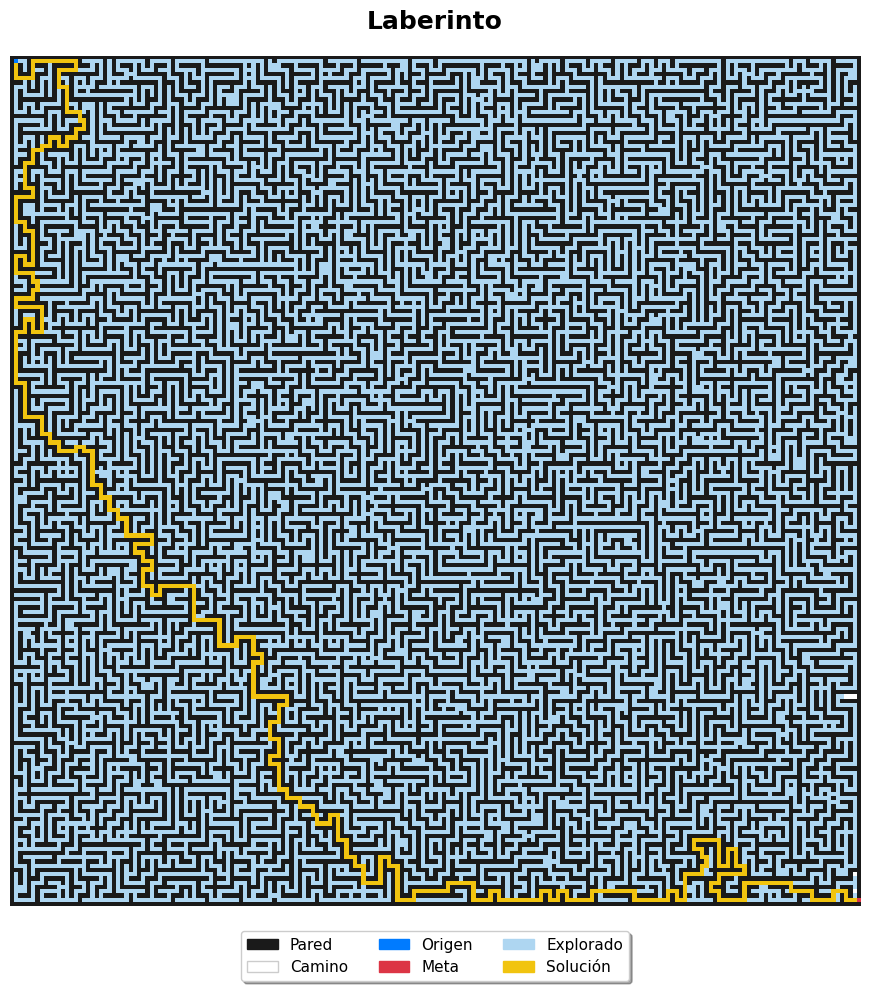

{'tiempo': 0.1196894645690918, 'visitados': 20788, 'camino': 646}

In [6]:
class BFS:# clase que describe el comportamiento y atributos de los nodos para este método
  def __init__(self, y, x, padre=None):# función que define que atributos tiene cada nodo en este caso un nodo padre que se asignara luego y sus coordenadas de fila y columna
    self.y = y
    self.x = x
    self.padre = padre

  def obtener_posicion(self):# función que resume los atributos de fila y columna como una dupla
    return (self.y, self.x)


def camino_BFS(Matriz_original, graficar=True): # función que busca el camino que resuelve el laberinto

  laberinto_BFS = copy.deepcopy(Matriz_original) # genero una copia de la matriz de caminos del laberinto original que funcionara como el mapa en donde se mueve el algoritmo
  tiempo_ini_BFS = time.time() # función para calcular el tiempo que tarda en ejecutarse todo el algoritmo
  origen_BFS = obtener_posicion(laberinto_BFS, ORIGEN) # variable que almacena la posición del origen del laberinto
  nodo_or_BFS = BFS(origen_BFS[0], origen_BFS[1]) # variable que crea el nodo origen como una dupla
  queue = [nodo_or_BFS] # lista que almacenará los nodos con el método pila (QUEUE)
  visitados = set() # conjunto que almacena las coordenadas de los nodos visitados, este conjunto no permite repetidos
  visitados.add(nodo_or_BFS.obtener_posicion()) # almacena las coordenadas del origen en el conjunto
  movimientos = [(1, 0), (-1, 0), (0, 1), (0, -1)] # declara los movimientos posibles como duplas
  nodo_meta = None # variable que luego es reemplazada para terminar el ciclo

  while len(queue) > 0: # mientras hallan nodos por visitar
    nodo_actual = queue.pop(0)# crea un nodo que almacena la primera dupla que entro y elimina esa misma dupla de la lista (FIFO)
    if laberinto_BFS[nodo_actual.y][nodo_actual.x] == META:# verifica si las coordenadas se corresponden con la meta del laberinto original
      nodo_meta = nodo_actual# reemplaza el valor de nodo meta por el nodo actual y termina el ciclo
      break
    if laberinto_BFS[nodo_actual.y][nodo_actual.x] not in (ORIGEN, META): # verifica si las coordenadas se corresponden con las del origen y la meta del laberinto original
      laberinto_BFS[nodo_actual.y][nodo_actual.x] = VISITADO # define una variable que almacena la dupla de coordenadas para el nodo actual
    for dy, dx in movimientos: # iteración que crea los siguientes nodos a explorar
      y_hijo = nodo_actual.y + dy # siguiente fila para el nodo hijo
      x_hijo = nodo_actual.x + dx # siguiente columna para el nodo hijo

      if 0 <= y_hijo < len(laberinto_BFS) and 0 <= x_hijo < len(laberinto_BFS[0]):# verifica que cada coordenada del hijo esté dentro de la matriz de caminos
        posicion_hijo = (y_hijo, x_hijo) # declara una variable que almacena la dupla de coordenadas del nodo hijo

        if (laberinto_BFS[y_hijo][x_hijo] in (CAMINO, ORIGEN, META) and posicion_hijo not in visitados):# verifica si la dupla es un camino, el origen o la meta
          visitados.add(posicion_hijo) #añade la dupla del nodo hijo a el conjunto
          nodo_hijo = BFS(y_hijo, x_hijo, padre=nodo_actual)# crea una variable que corresponde a el nodo hijo, y le asigna como padre el nodo actual
          queue.append(nodo_hijo) # añade el nodo hijo a la pila (stack)

  fin_tiempo_BFS = time.time() # luego de que el algoritmo encuentre la meta, para el cronometro y almacena el tiempo que tardo en una variable
  tiempo_ej_BFS = fin_tiempo_BFS - tiempo_ini_BFS # calcula el tiempo de ejecución
  n_tuplas = []# lista que almacena de atras hacia adelante las duplas de cada nodo

  if nodo_meta is not None:# verifica si se encontro una meta
    paso_actual = nodo_meta# declara una variable que almacena la dupla del nodo meta

    while paso_actual is not None:# opera mientras el nodo actual no sea ninguno
      n_tuplas.append(paso_actual.obtener_posicion())# añade la dupla del nodo actual a la lista de n-tuplas
      paso_actual = paso_actual.padre# declara el nodo padre como el nuevo nodo actual
    n_tuplas.reverse()# voltea la lista completa para que quede de inicio a la meta

    for y, x in n_tuplas:# iteración que asigna el valor 5 a el camino solución
      if laberinto_BFS[y][x] not in (ORIGEN, META):# verifica que no es el origen ni la meta
        laberinto_BFS[y][x] = SOLUCION

    if graficar:
      print(f"¡Éxito! Camino encontrado con {len(n_tuplas)} pasos.\n")
      print(f"Tiempo de ejecución: {tiempo_ej_BFS} segundos\n")
      print(f"Conjunto de tuplas en la solución (Y, X):\n")
      print(n_tuplas)
      dibujar_laberinto_grafico(laberinto_BFS)
  else:
      if graficar:
          print("No se encontró ruta hacia la meta.")

  return {"tiempo": tiempo_ej_BFS,"visitados": len(visitados),"camino": len(n_tuplas) if nodo_meta else 0,}


camino_BFS(laberinto_1, graficar=True)

# A*

¡Éxito! Camino encontrado con 646 pasos.

Tiempo de ejecución: 1.633061170578003 segundos

Conjunto de tuplas en la solución (Y, X):

[(1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (5, 2), (5, 3), (5, 4), (5, 5), (4, 5), (3, 5), (2, 5), (1, 5), (1, 6), (1, 7), (1, 8), (1, 9), (1, 10), (1, 11), (1, 12), (1, 13), (1, 14), (1, 15), (2, 15), (3, 15), (3, 14), (3, 13), (3, 12), (3, 11), (4, 11), (5, 11), (6, 11), (7, 11), (7, 12), (7, 13), (8, 13), (9, 13), (10, 13), (11, 13), (12, 13), (13, 13), (13, 14), (13, 15), (13, 16), (14, 16), (15, 16), (15, 17), (16, 17), (17, 17), (17, 16), (17, 15), (18, 15), (19, 15), (19, 14), (19, 13), (20, 13), (21, 13), (21, 12), (21, 11), (20, 11), (19, 11), (19, 10), (19, 9), (20, 9), (21, 9), (21, 8), (21, 7), (22, 7), (22, 6), (22, 5), (23, 5), (24, 5), (25, 5), (25, 4), (25, 3), (26, 3), (27, 3), (28, 3), (29, 3), (30, 3), (31, 3), (31, 4), (31, 5), (32, 5), (33, 5), (33, 4), (33, 3), (33, 2), (33, 1), (34, 1), (35, 1), (36, 1), (37, 1), (38, 1), (39, 1), (3

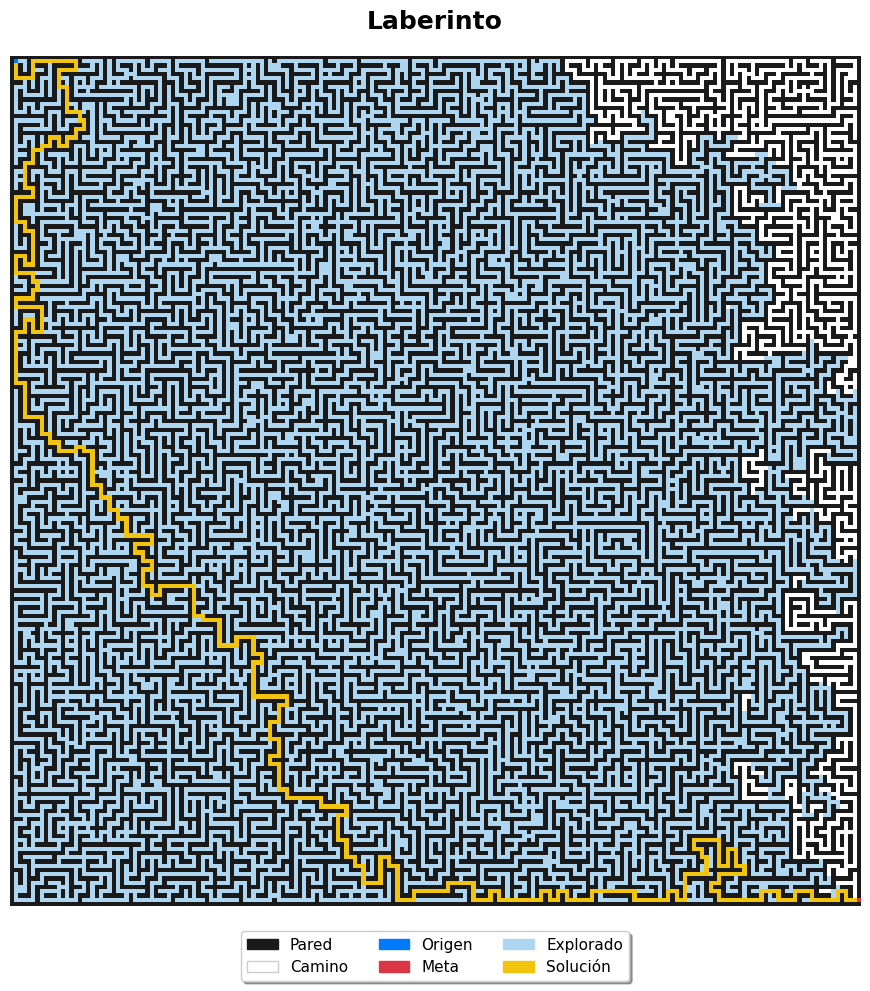

{'tiempo': 1.633061170578003, 'visitados': 18965, 'camino': 646}

In [7]:
class AS:# clase que describe el comportamiento y atributos de los nodos para este método
  def __init__(self, y, x,recorrido=0, padre=None): # función que define que atributos tiene cada nodo en este caso un nodo padre, una heuristica y un valor que es la suma del total de pasos y la heuristica, por último sus coordenadas de fila y columna
    self.y = y
    self.x = x
    self.recorrido = recorrido
    self.heuristica = 0
    self.padre = padre
    self.valor = 0
  def obtener_posicion(self):# función que resume los atributos de fila y columna como una dupla
    return (self.y, self.x)
  def __lt__(self,otro): #función que compara los valores de cada nodo y organizará luego de menor a mayor
    return self.valor < otro.valor
def camino_AS(Matriz_original, graficar=True): # función que busca el camino que resuelve el laberinto
  laberinto_AS = copy.deepcopy(Matriz_original)# genero una copia de la matriz de caminos del laberinto original que funcionara como el mapa en donde se mueve el algoritmo

  tiempo_ini_AS = time.time()# función para calcular el tiempo que tarda en ejecutarse todo el algoritmo

  origen_AS = obtener_posicion(laberinto_AS, ORIGEN)# variable que almacena la dupla del origen del laberinto
  nodo_or_AS = AS(origen_AS[0], origen_AS[1], recorrido=0) # variable que crea el nodo origen como una dupla adicionando un valor recorrido que importa para clasificar los nodos por su distancia a la meta
  meta_AS = obtener_posicion(laberinto_AS,META) # variable que almacena la dupla de la meta del laberinto
  nodo_meta_AS = AS(meta_AS[0], meta_AS[1]) # variable que almacena el nodo de la meta del laberinto
  nodo_or_AS.heuristica = ((nodo_or_AS.y - nodo_meta_AS.y)**2 +(nodo_or_AS.x - nodo_meta_AS.x)**2)**(1/2) # variable que almacena la distancia del nodo del origen a la meta
  nodo_or_AS.valor = nodo_or_AS.recorrido + nodo_or_AS.heuristica # variable que almacena la distancia del nodo a la meta más el número de casillas recorridas hasta el nodo

  order_list = [nodo_or_AS]# lista que almacenará los nodos

  visitados = set()# conjunto que almacena las coordenadas de los nodos visitados, este conjunto no permite repetidos
  visitados.add(nodo_or_AS.obtener_posicion())# almacena las coordenadas del origen en un conjunto

  movimientos = [(1, 0), (-1, 0), (0, 1), (0, -1)]# declara los movimientos posibles como duplas
  nodo_meta = None# variable que luego es reemplazada para terminar el ciclo
  while len(order_list) > 0:
    nodo_actual = min(order_list)# Organiza la order list y declara la variable del nodo actual como el que tiene el valor menor (distancia del nodo a la meta más el número de casillas recorridas hasta el nodo)
    order_list.remove(nodo_actual) # elimina el elemento de la order list
    posicion_actual = nodo_actual.obtener_posicion()# variable que almacena las coordenadas del nodo actual
    visitados.add(posicion_actual)
    if posicion_actual in visitados:
      pass
    if laberinto_AS[nodo_actual.y][nodo_actual.x] == META:# verifica si las coordenadas se corresponden con la meta del laberinto original
      nodo_meta = nodo_actual# reemplaza el valor de nodo meta por el nodo actual y termina el ciclo
      break

    if laberinto_AS[nodo_actual.y][nodo_actual.x] not in (ORIGEN, META):# verifica si las coordenadas se corresponden con las del origen y la meta del laberinto original
      laberinto_AS[nodo_actual.y][nodo_actual.x] = VISITADO# define una variable que almacena la dupla de coordenadas para el nodo actual

    for dy, dx in movimientos:# iteración que crea los siguientes nodos a explorar
      y_hijo = nodo_actual.y + dy# siguiente fila para el nodo hijo
      x_hijo = nodo_actual.x + dx# siguiente columna para el nodo hijo

      if 0 <= y_hijo < len(laberinto_AS) and 0 <= x_hijo < len(laberinto_AS[0]):# verifica que cada coordenada del hijo esté dentro de la matriz de caminos
        posicion_hijo = (y_hijo, x_hijo)# declara una variable que almacena la dupla de coordenadas del nodo hijo

        if laberinto_AS[y_hijo][x_hijo] in (CAMINO, ORIGEN, META) and posicion_hijo not in visitados:# verifica si la dupla es un camino, el origen o la meta
          visitados.add(posicion_hijo)
          nodo_hijo = AS(y_hijo, x_hijo,recorrido=nodo_actual.recorrido + 1, padre=nodo_actual)
          nodo_hijo.heuristica = ((nodo_hijo.y - nodo_meta_AS.y)**2 +(nodo_hijo.x - nodo_meta_AS.x)**2)**(1/2)
          nodo_hijo.valor = nodo_hijo.recorrido + nodo_hijo.heuristica
          order_list.append(nodo_hijo)

  fin_tiempo_AS = time.time()
  tiempo_ej_AS = fin_tiempo_AS - tiempo_ini_AS
  n_tuplas = []
  if nodo_meta is not None:
    paso_actual = nodo_meta

    while paso_actual is not None:
      n_tuplas.append(paso_actual.obtener_posicion())
      paso_actual = paso_actual.padre

    n_tuplas.reverse()

    for y, x in n_tuplas:
      if laberinto_AS[y][x] not in (ORIGEN, META):
        laberinto_AS[y][x] = SOLUCION

    if graficar:
      print(f'¡Éxito! Camino encontrado con {len(n_tuplas)} pasos.\n')
      print(f'Tiempo de ejecución: {tiempo_ej_AS} segundos\n')
      print(f'Conjunto de tuplas en la solución (Y, X):\n')
      print(n_tuplas)

      dibujar_laberinto_grafico(laberinto_AS)
  else:
    if graficar:
        print('No se encontró ruta hacia la meta.')

  return {
    "tiempo": tiempo_ej_AS,
    "visitados": len(visitados),
    "camino": len(n_tuplas) if nodo_meta else 0
  }



camino_AS(laberinto_1, graficar=True)

# DIJIkSTRA

¡Éxito! Camino encontrado con 646 pasos.

Tiempo de ejecución: 0.6699850559234619 segundos

Conjunto de tuplas en la solución (Y, X):

[(1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (5, 2), (5, 3), (5, 4), (5, 5), (4, 5), (3, 5), (2, 5), (1, 5), (1, 6), (1, 7), (1, 8), (1, 9), (1, 10), (1, 11), (1, 12), (1, 13), (1, 14), (1, 15), (2, 15), (3, 15), (3, 14), (3, 13), (3, 12), (3, 11), (4, 11), (5, 11), (6, 11), (7, 11), (7, 12), (7, 13), (8, 13), (9, 13), (10, 13), (11, 13), (12, 13), (13, 13), (13, 14), (13, 15), (13, 16), (14, 16), (15, 16), (15, 17), (16, 17), (17, 17), (17, 16), (17, 15), (18, 15), (19, 15), (19, 14), (19, 13), (20, 13), (21, 13), (21, 12), (21, 11), (20, 11), (19, 11), (19, 10), (19, 9), (20, 9), (21, 9), (21, 8), (21, 7), (22, 7), (22, 6), (22, 5), (23, 5), (24, 5), (25, 5), (25, 4), (25, 3), (26, 3), (27, 3), (28, 3), (29, 3), (30, 3), (31, 3), (31, 4), (31, 5), (32, 5), (33, 5), (33, 4), (33, 3), (33, 2), (33, 1), (34, 1), (35, 1), (36, 1), (37, 1), (38, 1), (39, 1), (

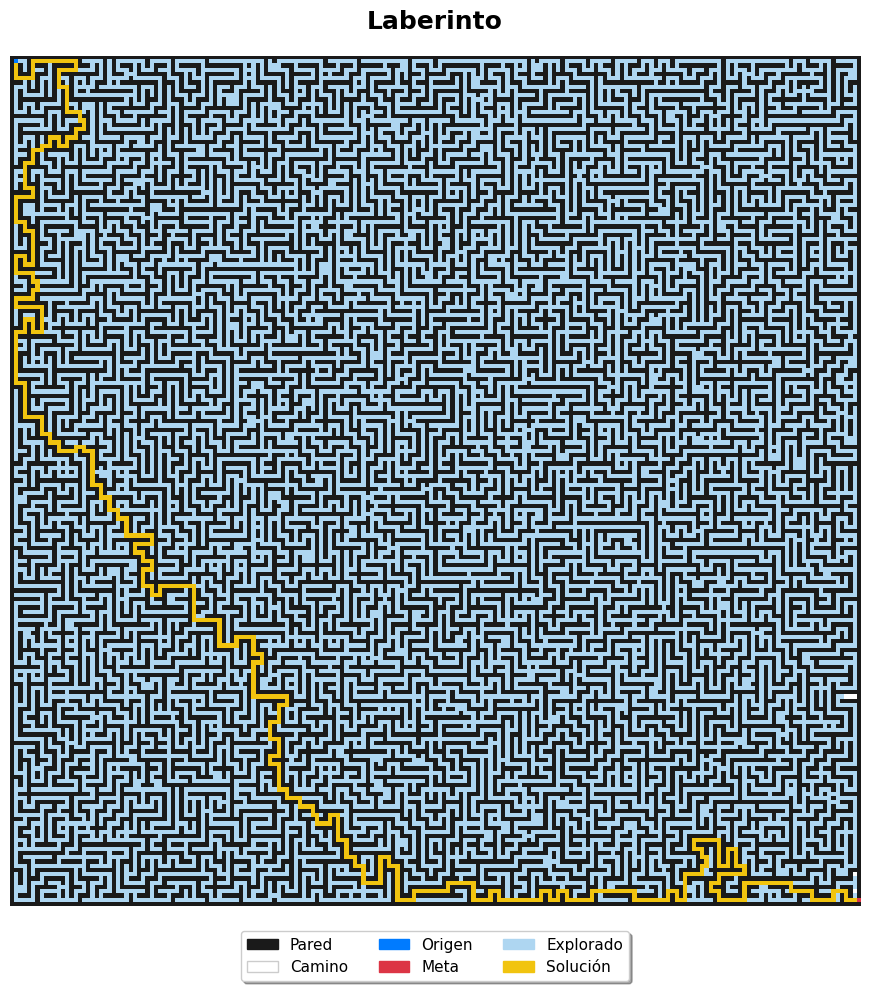

{'tiempo': 0.6699850559234619, 'visitados': 20788, 'camino': 646}

In [8]:
class DIJIKSTRA:
  def __init__(self, y, x,recorrido=0, padre=None):
    self.y = y
    self.x = x
    self.recorrido = recorrido
    self.padre = padre
  def obtener_posicion(self):
    return (self.y, self.x)
  def __lt__(self,otro):
    return self.recorrido < otro.recorrido
def camino_DIJIKSTRA(Matriz_original, graficar=True):
  laberinto_DIJIKSTRA = copy.deepcopy(Matriz_original)

  tiempo_ini_DIJIKSTRA = time.time()

  origen_DIJIKSTRA = obtener_posicion(laberinto_DIJIKSTRA, ORIGEN)
  nodo_or_DIJIKSTRA = DIJIKSTRA(origen_DIJIKSTRA[0], origen_DIJIKSTRA[1], recorrido=0)
  meta_DIJIKSTRA = obtener_posicion(laberinto_DIJIKSTRA,META)
  nodo_meta_DIJIKSTRA =DIJIKSTRA(meta_DIJIKSTRA[0], meta_DIJIKSTRA[1])
  order_list = [nodo_or_DIJIKSTRA]

  visitados = set()
  visitados.add(nodo_or_DIJIKSTRA.obtener_posicion())

  movimientos = [(1, 0), (-1, 0), (0, 1), (0, -1)]
  nodo_meta = None
  while len(order_list) > 0:
    nodo_actual = min(order_list)
    order_list.remove(nodo_actual)
    posicion_actual = nodo_actual.obtener_posicion()

    visitados.add(posicion_actual)
    if posicion_actual in visitados:
      pass
    if laberinto_DIJIKSTRA[nodo_actual.y][nodo_actual.x] == META:
      nodo_meta = nodo_actual
      break

    if laberinto_DIJIKSTRA[nodo_actual.y][nodo_actual.x] not in (ORIGEN, META):
      laberinto_DIJIKSTRA[nodo_actual.y][nodo_actual.x] = VISITADO

    for dy, dx in movimientos:
      y_hijo = nodo_actual.y + dy
      x_hijo = nodo_actual.x + dx

      if 0 <= y_hijo < len(laberinto_DIJIKSTRA) and 0 <= x_hijo < len(laberinto_DIJIKSTRA[0]):
        posicion_hijo = (y_hijo, x_hijo)

        if laberinto_DIJIKSTRA[y_hijo][x_hijo] in (CAMINO, ORIGEN, META) and posicion_hijo not in visitados:
          visitados.add(posicion_hijo)
          nodo_hijo = DIJIKSTRA(y_hijo, x_hijo,recorrido=nodo_actual.recorrido + 1, padre=nodo_actual)
          order_list.append(nodo_hijo)

  fin_tiempo_DIJIKSTRA = time.time()
  tiempo_ej_DIJIKSTRA = fin_tiempo_DIJIKSTRA - tiempo_ini_DIJIKSTRA
  n_tuplas = []
  if nodo_meta is not None:
    paso_actual = nodo_meta

    while paso_actual is not None:
      n_tuplas.append(paso_actual.obtener_posicion())
      paso_actual = paso_actual.padre

    n_tuplas.reverse()

    for y, x in n_tuplas:
      if laberinto_DIJIKSTRA[y][x] not in (ORIGEN, META):
        laberinto_DIJIKSTRA[y][x] = SOLUCION

    if graficar:
      print(f'¡Éxito! Camino encontrado con {len(n_tuplas)} pasos.\n')
      print(f'Tiempo de ejecución: {tiempo_ej_DIJIKSTRA} segundos\n')
      print(f'Conjunto de tuplas en la solución (Y, X):\n')
      print(n_tuplas)

      dibujar_laberinto_grafico(laberinto_DIJIKSTRA)
  else:
    if graficar:
        print('No se encontró ruta hacia la meta.')

  return {
    "tiempo": tiempo_ej_DIJIKSTRA,
    "visitados": len(visitados),
    "camino": len(n_tuplas) if nodo_meta else 0
  }

camino_DIJIKSTRA(laberinto_1, graficar=True)

# Greethy

¡Éxito! Camino encontrado con 988 pasos.

Tiempo de ejecución: 0.05346250534057617 segundos

Conjunto de tuplas en la solución (Y, X):

[(1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (5, 2), (5, 3), (6, 3), (7, 3), (8, 3), (9, 3), (9, 4), (9, 5), (9, 6), (9, 7), (8, 7), (7, 7), (6, 7), (5, 7), (5, 8), (5, 9), (4, 9), (3, 9), (2, 9), (1, 9), (1, 10), (1, 11), (1, 12), (1, 13), (1, 14), (1, 15), (2, 15), (3, 15), (3, 16), (3, 17), (3, 18), (3, 19), (2, 19), (1, 19), (1, 20), (1, 21), (2, 21), (3, 21), (4, 21), (5, 21), (5, 20), (5, 19), (6, 19), (7, 19), (7, 18), (8, 18), (9, 18), (9, 19), (9, 20), (9, 21), (9, 22), (9, 23), (9, 24), (9, 25), (9, 26), (9, 27), (10, 27), (11, 27), (11, 26), (11, 25), (11, 24), (11, 23), (12, 23), (13, 23), (13, 24), (13, 25), (14, 25), (15, 25), (15, 26), (15, 27), (15, 28), (15, 29), (14, 29), (13, 29), (13, 30), (13, 31), (13, 32), (13, 33), (12, 33), (11, 33), (11, 34), (11, 35), (10, 35), (9, 35), (8, 35), (7, 35), (6, 35), (5, 35), (5, 34), (5, 33), (5, 32

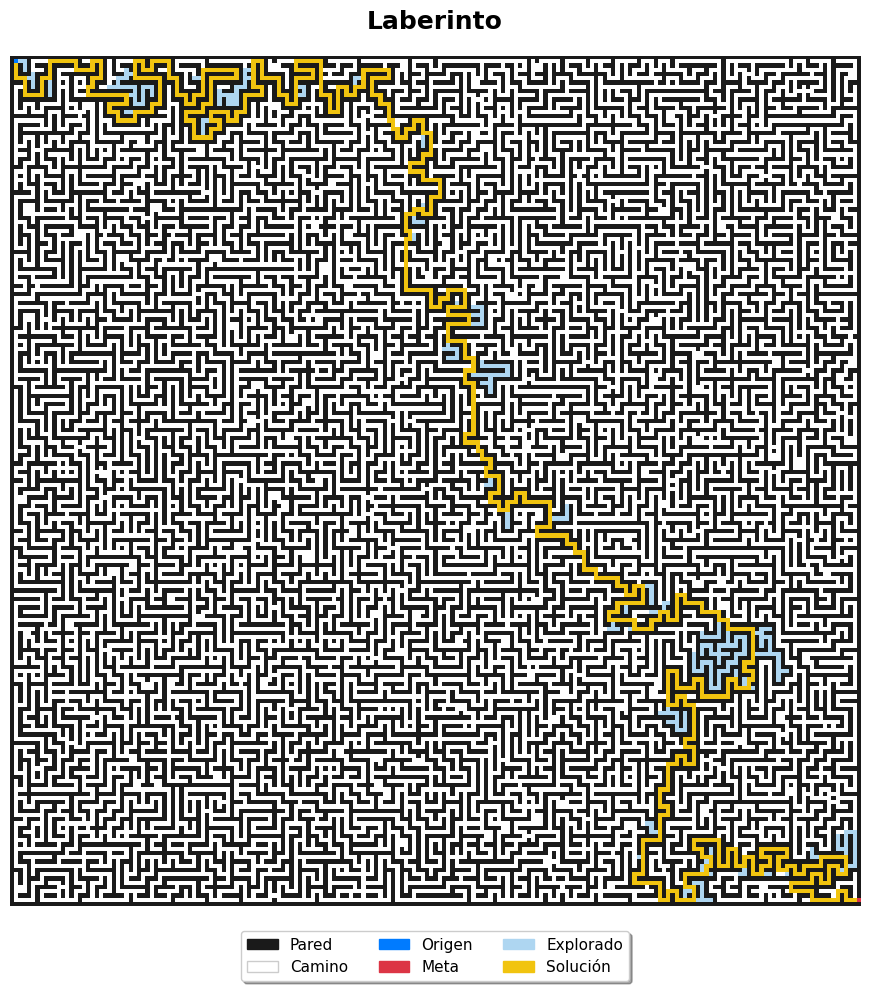

{'tiempo': 0.05346250534057617, 'visitados': 1465, 'camino': 988}

In [9]:
class GTY:
  def __init__(self, y, x, padre=None):
    self.y = y
    self.x = x
    self.heuristica = 0
    self.padre = padre
  def obtener_posicion(self):
    return (self.y, self.x)
  def __lt__(self,otro):
    return self.heuristica < otro.heuristica
def camino_GTY(Matriz_original, graficar=True):
  laberinto_GTY = copy.deepcopy(Matriz_original)

  tiempo_ini_GTY = time.time()

  origen_GTY = obtener_posicion(laberinto_GTY, ORIGEN)
  nodo_or_GTY = GTY(origen_GTY[0], origen_GTY[1])
  meta_GTY = obtener_posicion(laberinto_GTY,META)
  nodo_meta_GTY = GTY(meta_GTY[0], meta_GTY[1])
  nodo_or_GTY.heuristica = ((nodo_or_GTY.y - nodo_meta_GTY.y)**2 +(nodo_or_GTY.x - nodo_meta_GTY.x)**2)**(1/2)

  order_list = [nodo_or_GTY]

  visitados = set()
  visitados.add(nodo_or_GTY.obtener_posicion())

  movimientos = [(1, 0), (-1, 0), (0, 1), (0, -1)]
  nodo_meta = None
  while len(order_list) > 0:
    nodo_actual = min(order_list)
    order_list.remove(nodo_actual)
    posicion_actual = nodo_actual.obtener_posicion()

    visitados.add(posicion_actual)
    if posicion_actual in visitados:
      pass
    if laberinto_GTY[nodo_actual.y][nodo_actual.x] == META:
      nodo_meta = nodo_actual
      break


    if laberinto_GTY[nodo_actual.y][nodo_actual.x] not in (ORIGEN, META):
      laberinto_GTY[nodo_actual.y][nodo_actual.x] = VISITADO

    for dy, dx in movimientos:
      y_hijo = nodo_actual.y + dy
      x_hijo = nodo_actual.x + dx

      if 0 <= y_hijo < len(laberinto_GTY) and 0 <= x_hijo < len(laberinto_GTY[0]):
        posicion_hijo = (y_hijo, x_hijo)

        if laberinto_GTY[y_hijo][x_hijo] in (CAMINO, ORIGEN, META) and posicion_hijo not in visitados:
          visitados.add(posicion_hijo)
          nodo_hijo = GTY(y_hijo, x_hijo, padre=nodo_actual)
          nodo_hijo.heuristica = ((nodo_hijo.y - nodo_meta_GTY.y)**2 +(nodo_hijo.x - nodo_meta_GTY.x)**2)**(1/2)
          order_list.append(nodo_hijo)

  fin_tiempo_GTY = time.time()
  tiempo_ej_GTY = fin_tiempo_GTY - tiempo_ini_GTY
  n_tuplas = []
  if nodo_meta is not None:
    paso_actual = nodo_meta

    while paso_actual is not None:
      n_tuplas.append(paso_actual.obtener_posicion())
      paso_actual = paso_actual.padre

    n_tuplas.reverse()

    for y, x in n_tuplas:
      if laberinto_GTY[y][x] not in (ORIGEN, META):
        laberinto_GTY[y][x] = SOLUCION

    if graficar:
      print(f'¡Éxito! Camino encontrado con {len(n_tuplas)} pasos.\n')
      print(f'Tiempo de ejecución: {tiempo_ej_GTY} segundos\n')
      print(f'Conjunto de tuplas en la solución (Y, X):\n')
      print(n_tuplas)

      dibujar_laberinto_grafico(laberinto_GTY)
  else:
    if graficar:
        print('No se encontró ruta hacia la meta.')

  return {
    "tiempo": tiempo_ej_GTY,
    "visitados": len(visitados),
    "camino": len(n_tuplas) if nodo_meta else 0
  }



camino_GTY(laberinto_1, graficar=True)

# Tabla Comparación

In [10]:
def comparar_todos(matriz_original):

    DFS = camino_DFS(matriz_original, graficar=False)
    BFS = camino_BFS(matriz_original, graficar=False)
    DIJIKSTRA = camino_DIJIKSTRA(matriz_original, graficar=False)
    AS = camino_AS(matriz_original, graficar=False)
    GTY = camino_GTY(matriz_original, graficar=False)

    print("\n" + "="*85)
    print("Análisis y Comparación")
    print("="*85)

    print(f"| {'Métrica':<30} | {'DFS':<10} | {'BFS':<10} | {'Dijikstra\'s':<10} | {'A*':<10} | {'Greethy':<10} |")
    print("| " + "-"*30 + " | " + "-"*10 + " | " + "-"*10 + " | " + "-"*10 + " | " + "-"*10 + " | " + "-"*10 + " |")

    t_dfs, t_bfs, t_dij = f"{DFS['tiempo']:.4f}s", f"{BFS['tiempo']:.4f}s", f"{DIJIKSTRA['tiempo']:.4f}s"
    t_astar, t_greethy = f"{AS['tiempo']:.4f}s", f"{GTY['tiempo']:.4f}s"
    print(f"| {'Tiempo de Ejecución':<30} | {t_dfs:<10} | {t_bfs:<10} | {t_dij:<10} | {t_astar:<10} | {t_greethy:<10} |")

    v_dfs, v_bfs, v_dij = str(DFS['visitados']), str(BFS['visitados']), str(DIJIKSTRA['visitados'])
    v_astar, v_greethy = str(AS['visitados']), str(GTY['visitados'])
    print(f"| {'Total Nodos Visitados':<30} | {v_dfs:<10} | {v_bfs:<10} | {v_dij:<10} | {v_astar:<10} | {v_greethy:<10} |")

    c_dfs, c_bfs, c_dij = str(DFS['camino']), str(BFS['camino']), str(DIJIKSTRA['camino'])
    c_astar, c_greethy = str(AS['camino']), str(GTY['camino'])
    print(f"| {'Longitud del Camino Solución':<30} | {c_dfs:<10} | {c_bfs:<10} | {c_dij:<10} | {c_astar:<10} | {c_greethy:<10} |")
    print("="*85)

comparar_todos(laberinto_1)

No se encontró ruta hacia la meta.

Análisis y Comparación
| Métrica                        | DFS        | BFS        | Dijikstra's | A*         | Greethy    |
| ------------------------------ | ---------- | ---------- | ---------- | ---------- | ---------- |
| Tiempo de Ejecución            | 0.2263s    | 0.1198s    | 0.3523s    | 0.6725s    | 0.0276s    |
| Total Nodos Visitados          | 14472      | 20788      | 20788      | 18965      | 1465       |
| Longitud del Camino Solución   | 6236       | 646        | 646        | 646        | 988        |
